# Altimetry Sampling

This notebook explores how satellite altimetry observations sample the sea-surface height (SSH) field, and how the choice of sampling strategy affects estimates of global mean sea level (GMSL).

Satellite altimeters measure SSH along ground tracks, but their coverage is limited: typical missions observe only within approximately ±66° latitude. On top of this geographic restriction, the continuous SSH field must be evaluated at a finite set of measurement locations. The question is: *how does the spatial density and arrangement of these sampling points influence the accuracy of the GMSL estimate derived from them?*

We address this by:

1. Constructing grid-based sampling patterns over the ocean, the altimetry band, and ice regions.
2. Visualising how these grids relate to the underlying SSH and ice-thickness fields.
3. Comparing surface-integrated ("ideal") GMSL estimates against point-sampled estimates at various grid spacings.
4. Quantifying the GMSL estimation error introduced by discrete sampling.

## Setup

In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

from pygeoinf import GaussianMeasure
from pyslfp import FingerPrint, IceModel, averaging_operator

from project import colors, error_plot
from pygeoinf_extras.operators import (
    point_averaging_area_weighted_operator,
    point_averaging_operator,
)
from pygeoinf_extras.stats import expectation, standard_dev
from pyslfp_extras.altimetry import GridPoints
from pyslfp_extras.ice_thickness import IceSheetChange
from pyslfp_extras.plotting import plot


In [2]:
lmax = 128
ALTIMETRY_LATITUDE_RANGE = 66.0

fp = FingerPrint(lmax=lmax)
fp.set_state_from_ice_ng(version=IceModel.ICE7G, date=0.0)
fp_op = fp.as_sobolev_linear_operator(
    2, fp.mean_sea_floor_radius * 0.1
)

ice_change = IceSheetChange.global_ice(
    finger_print=fp,
    finger_print_operator=fp_op,
    length_scale=0.2 * fp.mean_sea_floor_radius,
    pattern=IceSheetChange.UniformPattern(),
    ice_gmsl_std=0.001,
    gmsl_target_mean=0.01,
)

samples = ice_change.sample()

print(f"Truncation degree: {lmax}")
print(
    f"Altimetry latitude range: ±{ALTIMETRY_LATITUDE_RANGE}°"
)

Truncation degree: 128
Altimetry latitude range: ±66.0°


## General Altimetry

The `GridPoints` class constructs a regular latitude–longitude grid, expands the projection mask (ocean, altimetry band, or ice) through spherical harmonics at each candidate point, and retains only those points where the mask value exceeds the threshold. This gives a discrete sampling pattern that respects the geometry of the underlying domain.

Three factory methods cover the common use cases:

| Factory | Projection | Default spacing |
|---|---|---|
| `GridPoints.ocean` | Full ocean mask | 5° |
| `GridPoints.ocean_altimetry` | Altimetry band (±66°) | 5° |
| `GridPoints.ice` | Ice sheet regions | 5° |

### Ocean Altimetry Grid

We begin by overlaying the ocean-altimetry grid on a sample SSH field. A coarse 30° spacing makes the grid structure clearly visible.

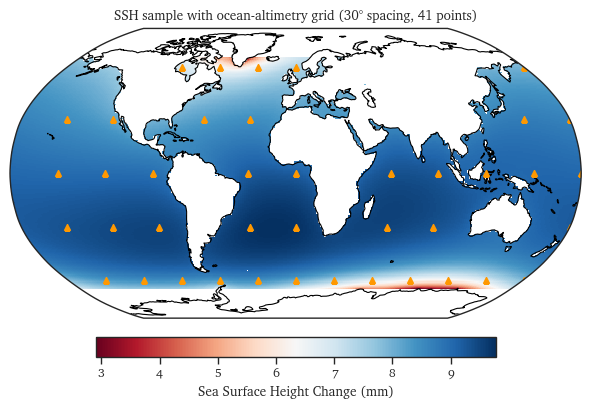

In [21]:
fig, ax, im = plot(
    samples.total_ssh * fp.altimetry_projection() * 1000,
    colorbar_label="Sea Surface Height Change (mm)",
)

grid_coarse = GridPoints.ocean_altimetry(
    fp,
    degree_spacing=30.0,
    latitude_range=ALTIMETRY_LATITUDE_RANGE,
)

ax.plot(
    grid_coarse.lons,
    grid_coarse.lats,
    "^",
    color=colors.ocean_altimetry,
    markersize=4,
    transform=ccrs.PlateCarree(),
)
ax.set_title(
    f"SSH sample with ocean-altimetry grid (30° spacing, {len(grid_coarse)} points)"
)
plt.show()

At a finer spacing (5°) the grid fills the altimetry band much more densely, which is closer to the resolution used in practice:

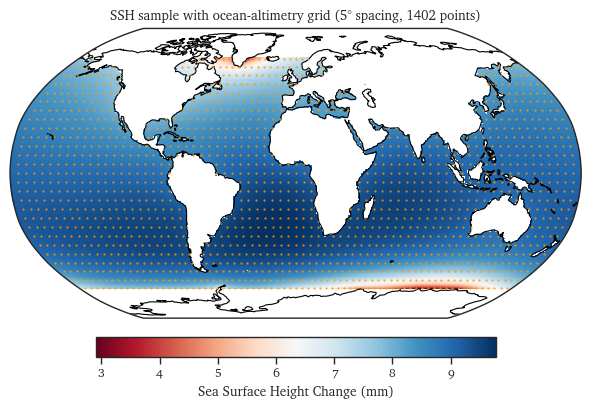

In [20]:
fig, ax, im = plot(
    samples.total_ssh * fp.altimetry_projection() * 1000,
    colorbar_label="Sea Surface Height Change (mm)",
)

grid_fine = GridPoints.ocean_altimetry(
    fp,
    degree_spacing=5.0,
    latitude_range=ALTIMETRY_LATITUDE_RANGE,
)

ax.plot(
    grid_fine.lons,
    grid_fine.lats,
    ".",
    color=colors.ocean_altimetry,
    markersize=1,
    transform=ccrs.PlateCarree(),
)
ax.set_title(
    f"SSH sample with ocean-altimetry grid (5° spacing, {len(grid_fine)} points)"
)
plt.show()

### Ice Altimetry Grid

A separate grid covers the ice sheet regions. Ice altimetry satellites (e.g. CryoSat-2, ICESat-2) sample the ice sheets at high latitudes outside the standard ocean altimetry band.

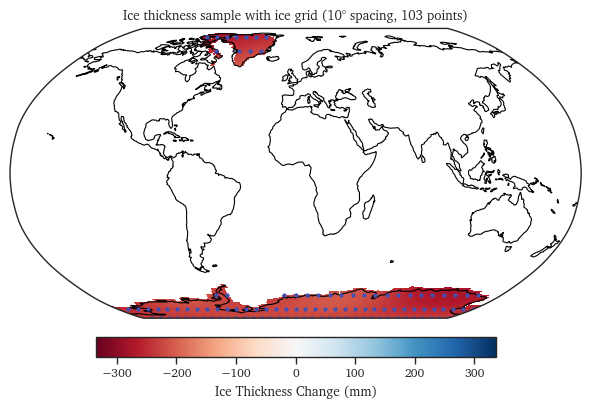

In [24]:
fig, ax, im = plot(
    samples.total_thickness * fp.ice_projection() * 1000,
    colorbar_label="Ice Thickness Change (mm)",
    symmetric=True,
)

ice_grid = GridPoints.ice(fp, degree_spacing=10.0)

ax.plot(
    ice_grid.lons,
    ice_grid.lats,
    ".",
    color=colors.ice_altimetry,
    markersize=4,
    transform=ccrs.PlateCarree(),
)
ax.set_title(
    f"Ice thickness sample with ice grid (10° spacing, {len(ice_grid)} points)"
)
plt.show()

## Point Evaluation

Given a grid of sampling locations, we construct a linear operator that evaluates the SSH field at each point. This point evaluation operator maps from the continuous function space to a finite-dimensional Euclidean space of SSH measurements.

As the forward model is linear and the prior is Gaussian, pushing the prior through the point evaluation operator yields an exact Gaussian distribution on the measurement vector — no Monte Carlo sampling is needed.

In [6]:
ssh_operator = ice_change.load_to_altimetry_ssh_operator
ssh_space = ssh_operator.codomain

ice_thickness_measure = ice_change.ice_thickness
load_measure = ice_change.total_load

# Point evaluation at the fine grid
point_eval_op = grid_fine.point_evaluation_operator(
    ssh_space
)
point_ssh_op = point_eval_op @ ssh_operator

# Push the load measure through to get the point SSH distribution
point_ssh_measure = load_measure.affine_mapping(
    operator=point_ssh_op
)

print(f"SSH space dimension: {ssh_space.dim}")
print(
    f"Number of sampling points: {point_ssh_op.codomain.dim}"
)
print(
    f"Point SSH expectation range: [{point_ssh_measure.expectation.min() * 1e3:.3f}, "
    f"{point_ssh_measure.expectation.max() * 1e3:.3f}] mm"
)

SSH space dimension: 16641
Number of sampling points: 1402
Point SSH expectation range: [4.158, 12.401] mm


## GMSL Estimation from Point Samples

The key question is how well we can recover Global Mean Sea Level (GMSL) from discrete altimetry samples. We compare three approaches:

1. **True GMSL** — the physically exact value from the sea-level equation, with no observation error.
2. **Continuous (surface integral)** — area-weighted integral of SSH over the altimetry band, using the exact spherical area element. This is the best we could do given the latitude restriction.
3. **Point-sampled estimate** — arithmetic mean of SSH at grid points, approximating the surface integral with a finite sum.

In [7]:
# True GMSL (no altimetry restriction)
true_gmsl = ice_thickness_measure.affine_mapping(
    operator=ice_change.ice_thickness_to_gmsl_operator
)

# Continuous surface-integral GMSL (altimetry band only)
continuous_gmsl = load_measure.affine_mapping(
    operator=ice_change.load_to_estimated_gmsl_operator
)

# Point-sampled GMSL (arithmetic mean of point evaluations)
point_avg_op = point_averaging_operator(
    point_ssh_op.codomain
)
point_gmsl = load_measure.affine_mapping(
    operator=point_avg_op @ point_ssh_op
)

print(
    f"True GMSL:       mean = {expectation(true_gmsl) * 1e3:.4f} mm,  "
    f"std = {standard_dev(true_gmsl) * 1e3:.4f} mm"
)
print(
    f"Continuous:      mean = {expectation(continuous_gmsl) * 1e3:.4f} mm,  "
    f"std = {standard_dev(continuous_gmsl) * 1e3:.4f} mm"
)
print(
    f"Point-sampled:   mean = {expectation(point_gmsl) * 1e3:.4f} mm,  "
    f"std = {standard_dev(point_gmsl) * 1e3:.4f} mm"
)

True GMSL:       mean = 10.0000 mm,  std = 1.0000 mm
Continuous:      mean = 9.8772 mm,  std = 0.9849 mm
Point-sampled:   mean = 9.6797 mm,  std = 0.9660 mm


We can visualise the estimation error between the true GMSL and the point-sampled estimate:

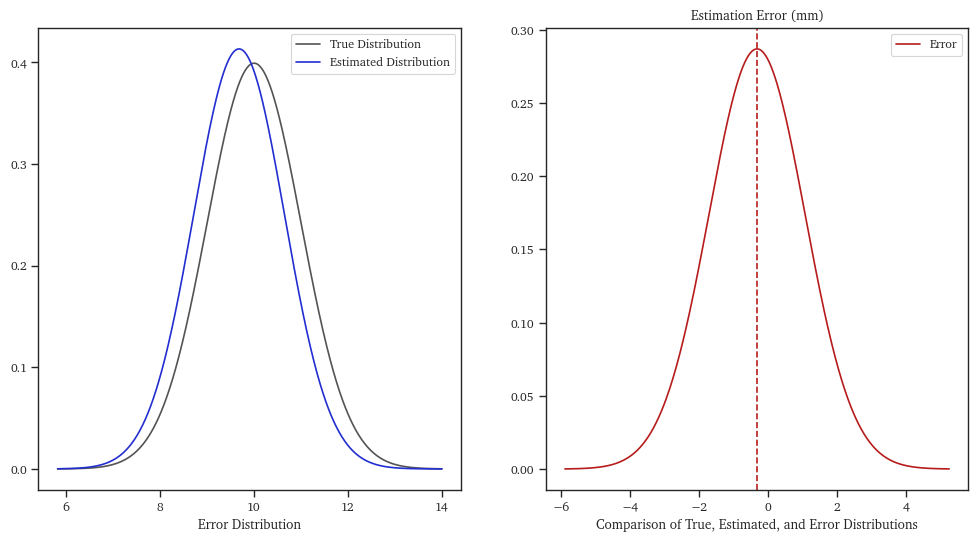

In [8]:
fig, (ax1, ax2) = error_plot(
    true_measure=true_gmsl * 1000,
    estimation_measure=point_gmsl * 1000,
    ax1_xlabel="GMSL Change (mm)",
    ax2_xlabel="Estimation Error (mm)",
)

## Sensitivity to Grid Spacing

The density of the sampling grid determines how well the discrete sum approximates the continuous integral. We sweep across a range of grid spacings and track how the GMSL estimate changes.

For each spacing, the pipeline is:

$$h \xrightarrow{\text{load}} q \xrightarrow{\text{SSH}} \eta \xrightarrow{\text{point eval}} \hat\eta_i \xrightarrow{\text{average}} \widehat{\text{GMSL}}$$

Because every step is a linear operator and the prior is Gaussian, the pushed-forward GMSL estimate is an exact scalar Gaussian whose mean and variance we read off analytically.

In [9]:
altimetry_spacings = [20, 15, 10, 5, 2.5]

results = {}

for spacing in altimetry_spacings:
    grid = GridPoints.ocean_altimetry(
        fp,
        degree_spacing=spacing,
        latitude_range=ALTIMETRY_LATITUDE_RANGE,
    )
    point_op = grid.point_evaluation_operator(ssh_space)
    gmsl_op = (
        point_averaging_operator(point_op.codomain)
        @ point_op
        @ ssh_operator
    )
    gmsl_est = load_measure.affine_mapping(operator=gmsl_op)
    results[spacing] = {
        "n_points": len(grid),
        "mean_mm": expectation(gmsl_est) * 1e3,
        "std_mm": standard_dev(gmsl_est) * 1e3,
    }
    print(
        f"Spacing {spacing:5.1f}°: {len(grid):5d} points, "
        f"mean = {results[spacing]['mean_mm']:.4f} mm, "
        f"std = {results[spacing]['std_mm']:.4f} mm"
    )

# Reference values
mu_true = expectation(true_gmsl) * 1e3
sd_true = standard_dev(true_gmsl) * 1e3
mu_cont = expectation(continuous_gmsl) * 1e3
sd_cont = standard_dev(continuous_gmsl) * 1e3
print(
    f"\nTrue GMSL:       mean = {mu_true:.4f} mm, std = {sd_true:.4f} mm"
)
print(
    f"Continuous:      mean = {mu_cont:.4f} mm, std = {sd_cont:.4f} mm"
)

Spacing  20.0°:    81 points, mean = 9.9258 mm, std = 0.9891 mm
Spacing  15.0°:   154 points, mean = 9.7113 mm, std = 0.9706 mm
Spacing  10.0°:   342 points, mean = 9.7536 mm, std = 0.9743 mm
Spacing   5.0°:  1402 points, mean = 9.6797 mm, std = 0.9660 mm
Spacing   2.5°:  5526 points, mean = 9.7296 mm, std = 0.9712 mm

True GMSL:       mean = 10.0000 mm, std = 1.0000 mm
Continuous:      mean = 9.8772 mm, std = 0.9849 mm


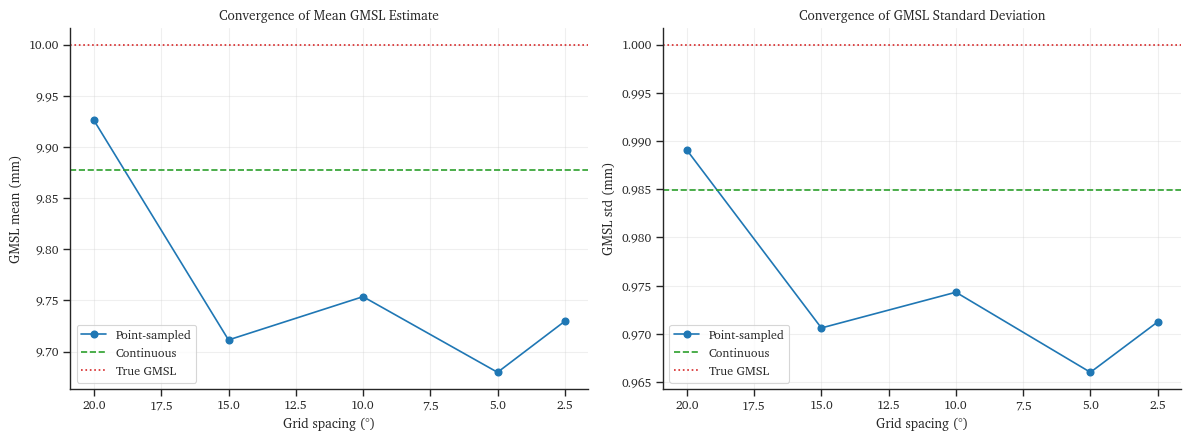

In [10]:
spacings = sorted(results.keys())
means = [results[s]["mean_mm"] for s in spacings]
stds = [results[s]["std_mm"] for s in spacings]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Mean convergence
ax = axes[0]
ax.plot(
    spacings,
    means,
    "o-",
    color="tab:blue",
    label="Point-sampled",
)
ax.axhline(
    mu_cont,
    color="tab:green",
    linestyle="--",
    label="Continuous",
)
ax.axhline(
    mu_true,
    color="tab:red",
    linestyle=":",
    label="True GMSL",
)
ax.set_xlabel("Grid spacing (°)")
ax.set_ylabel("GMSL mean (mm)")
ax.set_title("Convergence of Mean GMSL Estimate")
ax.legend()
ax.grid(alpha=0.3)
ax.invert_xaxis()

# Std convergence
ax = axes[1]
ax.plot(
    spacings,
    stds,
    "o-",
    color="tab:blue",
    label="Point-sampled",
)
ax.axhline(
    sd_cont,
    color="tab:green",
    linestyle="--",
    label="Continuous",
)
ax.axhline(
    sd_true,
    color="tab:red",
    linestyle=":",
    label="True GMSL",
)
ax.set_xlabel("Grid spacing (°)")
ax.set_ylabel("GMSL std (mm)")
ax.set_title("Convergence of GMSL Standard Deviation")
ax.legend()
ax.grid(alpha=0.3)
ax.invert_xaxis()

sns.despine()
plt.tight_layout()
plt.show()

## GMSL Averaging Comparison

When reducing discrete point measurements to a scalar GMSL estimate, not all averaging schemes are equal. A simple arithmetic mean ($1/N$) treats every point equally, but on a regular latitude–longitude grid the points are more densely packed near the poles. This overweights high-latitude SSH values in the average.

A more principled approach is to weight each point by $\cos(\text{latitude})$, which corrects for the shrinking area element toward the poles. This area-weighted mean provides a better approximation to the continuous surface integral.

We compare three GMSL estimators:

1. **Continuous** — the area-weighted surface integral over the altimetry band (reference).
2. **Unweighted point mean** — arithmetic mean $\frac{1}{N}\sum_i \eta_i$.
3. **Area-weighted point mean** — $\sum_i w_i \eta_i$ with $w_i = \cos(\phi_i) / \sum_j \cos(\phi_j)$.

Each operator is an affine map from the load space to a scalar, so the pushed-forward measure is an exact scalar Gaussian.

In [11]:
DEGREE_SPACING = 5.0

grid_points = GridPoints.ocean_altimetry(
    fp,
    degree_spacing=DEGREE_SPACING,
    latitude_range=ALTIMETRY_LATITUDE_RANGE,
)
latitudes = np.array(grid_points.lats)
print(
    f"Grid points: {len(grid_points)} at {DEGREE_SPACING}° spacing"
)

# Continuous area-weighted integral
gmsl_op_continuous = (
    ice_change.load_to_estimated_gmsl_operator
)

# Point SSH chain
point_eval_op_avg = grid_points.point_evaluation_operator(
    ssh_space
)
load_to_point_ssh = (
    point_eval_op_avg
    @ ice_change.load_to_altimetry_ssh_operator
)
point_ssh_space = load_to_point_ssh.codomain

# Unweighted (1/N) point mean
avg_unweighted = point_averaging_operator(point_ssh_space)
gmsl_op_unweighted = avg_unweighted @ load_to_point_ssh

# Area-weighted cos(lat) point mean
avg_area_weighted = point_averaging_area_weighted_operator(
    point_ssh_space, latitudes
)
gmsl_op_area_weighted = (
    avg_area_weighted @ load_to_point_ssh
)

Grid points: 1402 at 5.0° spacing


In [12]:
gmsl_continuous = load_measure.affine_mapping(
    operator=gmsl_op_continuous
)
gmsl_unweighted = load_measure.affine_mapping(
    operator=gmsl_op_unweighted
)
gmsl_area_weighted = load_measure.affine_mapping(
    operator=gmsl_op_area_weighted
)

mu_t = expectation(true_gmsl) * 1e3
mu_c = expectation(gmsl_continuous) * 1e3
mu_u = expectation(gmsl_unweighted) * 1e3
mu_aw = expectation(gmsl_area_weighted) * 1e3

sd_t = standard_dev(true_gmsl) * 1e3
sd_c = standard_dev(gmsl_continuous) * 1e3
sd_u = standard_dev(gmsl_unweighted) * 1e3
sd_aw = standard_dev(gmsl_area_weighted) * 1e3

print("=" * 52)
print(
    f"{'Method':<22}  {'Mean (mm)':>10}  {'Std (mm)':>10}"
)
print("=" * 52)
print(f"{'True GMSL':.<22}  {mu_t:>10.4f}  {sd_t:>10.4f}")
print(f"{'Continuous':.<22}  {mu_c:>10.4f}  {sd_c:>10.4f}")
print(f"{'Unweighted':.<22}  {mu_u:>10.4f}  {sd_u:>10.4f}")
print(
    f"{'Area-weighted':.<22}  {mu_aw:>10.4f}  {sd_aw:>10.4f}"
)
print("=" * 52)

Method                   Mean (mm)    Std (mm)
True GMSL.............     10.0000      1.0000
Continuous............      9.8772      0.9849
Unweighted............      9.6797      0.9660
Area-weighted.........      9.8429      0.9814


The three GMSL distributions are overlaid below. The upper panel shows the probability density functions; the lower panel shows the difference between each point-based method and the continuous reference:

/var/folders/kd/xfq9p6vj5js_kgtgyjz4djpm0000gn/T/ipykernel_15057/366180418.py:68: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Charter.
  plt.tight_layout()
/Users/th/Documents/pt-3-project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Charter.
  fig.canvas.print_figure(bytes_io, **kw)


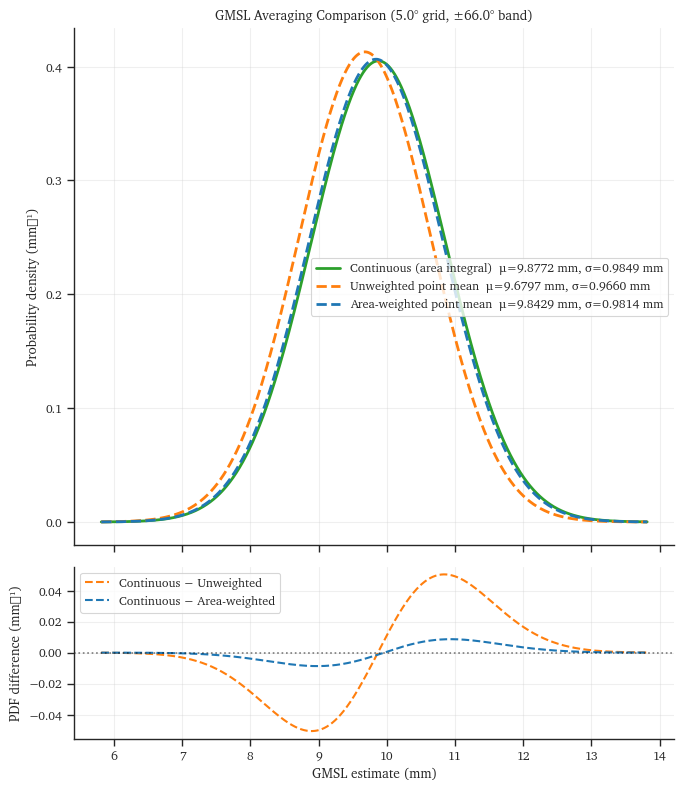

In [13]:
all_mus = [mu_c, mu_u, mu_aw]
all_sds = [sd_c, sd_u, sd_aw]

x_lo = min(m - 4 * s for m, s in zip(all_mus, all_sds))
x_hi = max(m + 4 * s for m, s in zip(all_mus, all_sds))
xs = np.linspace(x_lo, x_hi, 1000)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(7, 8),
    sharex=True,
    height_ratios=[3, 1],
)

styles = [
    ("Continuous (area integral)", "tab:green", "-"),
    ("Unweighted point mean", "tab:orange", "--"),
    ("Area-weighted point mean", "tab:blue", "--"),
]

for (label, color, ls), mu, sd in zip(
    styles, all_mus, all_sds
):
    ax1.plot(
        xs,
        norm.pdf(xs, loc=mu, scale=sd),
        color=color,
        linestyle=ls,
        linewidth=2,
        label=f"{label}  \u03bc={mu:.4f} mm, \u03c3={sd:.4f} mm",
    )

ax1.set_ylabel("Probability density (mm\u207b\u00b9)")
ax1.set_title(
    f"GMSL Averaging Comparison ({DEGREE_SPACING}\u00b0 grid, "
    f"\u00b1{ALTIMETRY_LATITUDE_RANGE}\u00b0 band)"
)
ax1.legend()
ax1.grid(alpha=0.3)

# Residuals
ax2.plot(
    xs,
    norm.pdf(xs, loc=mu_c, scale=sd_c)
    - norm.pdf(xs, loc=mu_u, scale=sd_u),
    color="tab:orange",
    linestyle="--",
    linewidth=1.5,
    label="Continuous \u2212 Unweighted",
)
ax2.plot(
    xs,
    norm.pdf(xs, loc=mu_c, scale=sd_c)
    - norm.pdf(xs, loc=mu_aw, scale=sd_aw),
    color="tab:blue",
    linestyle="--",
    linewidth=1.5,
    label="Continuous \u2212 Area-weighted",
)
ax2.axhline(0, color="black", linestyle=":", alpha=0.5)
ax2.set_xlabel("GMSL estimate (mm)")
ax2.set_ylabel("PDF difference (mm\u207b\u00b9)")
ax2.legend()
ax2.grid(alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

Area-weighted spacing  20.0°:    81 points, mean = 9.9822 mm, std = 0.9946 mm
Area-weighted spacing  15.0°:   154 points, mean = 9.8905 mm, std = 0.9877 mm
Area-weighted spacing  10.0°:   342 points, mean = 9.8708 mm, std = 0.9848 mm
Area-weighted spacing   5.0°:  1402 points, mean = 9.8429 mm, std = 0.9814 mm
Area-weighted spacing   2.5°:  5526 points, mean = 9.8730 mm, std = 0.9846 mm


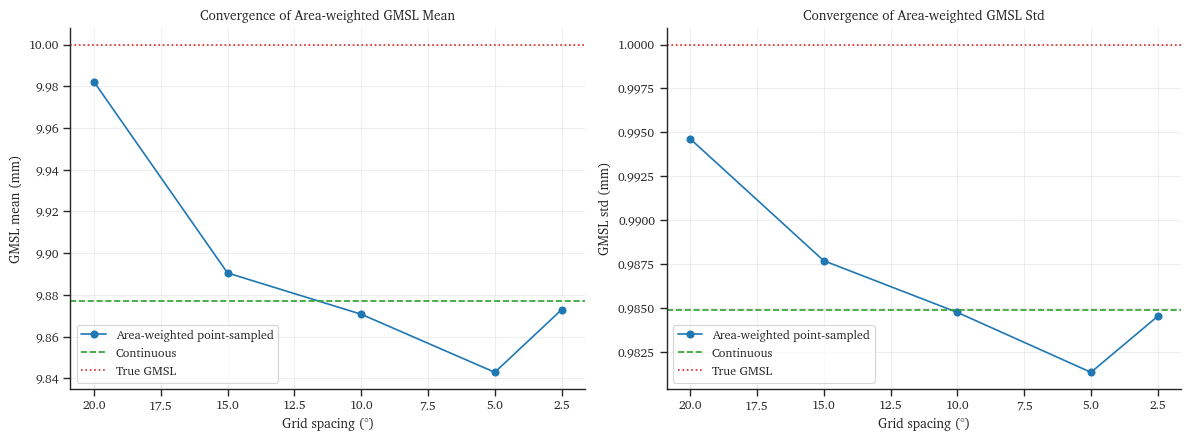

In [ ]:
# Convergence of area-weighted point-sampled GMSL with grid spacing
altimetry_spacings_area = [20, 15, 10, 5, 2.5]

area_results = {}

for spacing in altimetry_spacings_area:
    grid = GridPoints.ocean_altimetry(
        fp,
        degree_spacing=spacing,
        latitude_range=ALTIMETRY_LATITUDE_RANGE,
    )
    point_op = grid.point_evaluation_operator(ssh_space)
    lats = np.array(grid.lats)
    avg_aw = point_averaging_area_weighted_operator(
        point_op.codomain, lats
    )
    gmsl_op_aw = avg_aw @ point_op @ ssh_operator
    gmsl_est_aw = load_measure.affine_mapping(
        operator=gmsl_op_aw
    )

    area_results[spacing] = {
        "n_points": len(grid),
        "mean_mm": expectation(gmsl_est_aw) * 1e3,
        "std_mm": standard_dev(gmsl_est_aw) * 1e3,
    }

    print(
        f"Area-weighted spacing {spacing:5.1f}°: {len(grid):5d} points, "
        f"mean = {area_results[spacing]['mean_mm']:.4f} mm, "
        f"std = {area_results[spacing]['std_mm']:.4f} mm"
    )

mu_true_aw = expectation(true_gmsl) * 1e3
sd_true_aw = standard_dev(true_gmsl) * 1e3
mu_cont_aw = expectation(continuous_gmsl) * 1e3
sd_cont_aw = standard_dev(continuous_gmsl) * 1e3

spacings_aw = sorted(area_results.keys())
means_aw = [area_results[s]["mean_mm"] for s in spacings_aw]
stds_aw = [area_results[s]["std_mm"] for s in spacings_aw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Mean convergence
ax = axes[0]
ax.plot(
    spacings_aw,
    means_aw,
    "o-",
    color="tab:blue",
    label="Area-weighted point-sampled",
)
ax.axhline(
    mu_cont_aw,
    color="tab:green",
    linestyle="--",
    label="Continuous",
)
ax.axhline(
    mu_true_aw,
    color="tab:red",
    linestyle=":",
    label="True GMSL",
)
ax.set_xlabel("Grid spacing (°)")
ax.set_ylabel("GMSL mean (mm)")
ax.set_title("Convergence of Area-weighted GMSL Mean")
ax.legend()
ax.grid(alpha=0.3)
ax.invert_xaxis()

# Std convergence
ax = axes[1]
ax.plot(
    spacings_aw,
    stds_aw,
    "o-",
    color="tab:blue",
    label="Area-weighted point-sampled",
)
ax.axhline(
    sd_cont_aw,
    color="tab:green",
    linestyle="--",
    label="Continuous",
)
ax.axhline(
    sd_true_aw,
    color="tab:red",
    linestyle=":",
    label="True GMSL",
)
ax.set_xlabel("Grid spacing (°)")
ax.set_ylabel("GMSL std (mm)")
ax.set_title("Convergence of Area-weighted GMSL Std")
ax.legend()
ax.grid(alpha=0.3)
ax.invert_xaxis()

sns.despine()
plt.tight_layout()
plt.show()

## Summary

This notebook has demonstrated that:

1. **Geographic restriction matters** — limiting observations to ±66° latitude introduces a systematic bias in the GMSL estimate, since polar SSH signals are unobserved.
2. **Grid spacing converges** — as the point-sampling grid becomes finer, the discrete GMSL estimate converges toward the continuous surface integral. Spacings of ~5° or finer are typically sufficient.
3. **Averaging scheme matters** — a simple arithmetic mean over-represents high-latitude points on a regular lat–lon grid. Weighting by $\cos(\text{latitude})$ provides a better approximation to the true area-weighted integral.
4. **The SSH–SLC gap is spatially structured** — the estimation error from approximating SLC with SSH is not uniform; it has a characteristic geographic pattern tied to the gravitational and rotational fingerprint of the ice-mass source.

These sampling considerations are important context for the Bayesian inversions explored in later notebooks, where the observation operator encodes exactly these altimetry sampling choices.